## Experiment No: 6
## Experiment Title: Binary Classification using Logistic Regression - Confusion Matrix, Precision, Recall, F1-score

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay, 
    roc_curve,
    roc_auc_score
)

sns.set_theme(style="whitegrid")

print("Loading All Libraries and Packages...")

Loading All Libraries and Packages...


### Step 2: Load the DataSet

In [2]:
# Using the Breast Cancer Wisconsin dataset (real-world, open-access, built into sklearn)
# Target: 0 = malignant, 1 = benign (binary classification)
data = load_breast_cancer(as_frame=True)
df   = data.frame

print("Shape of dataset: ", df.shape)
print("target Classes: ", dict(zip(data.target.unique(), data.target_names)))
df.head()

Shape of dataset:  (569, 31)
target Classes:  {np.int64(0): np.str_('malignant'), np.int64(1): np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 3: Explore the DataSet

Class Distribution: 

target
1    357
0    212
Name: count, dtype: int64


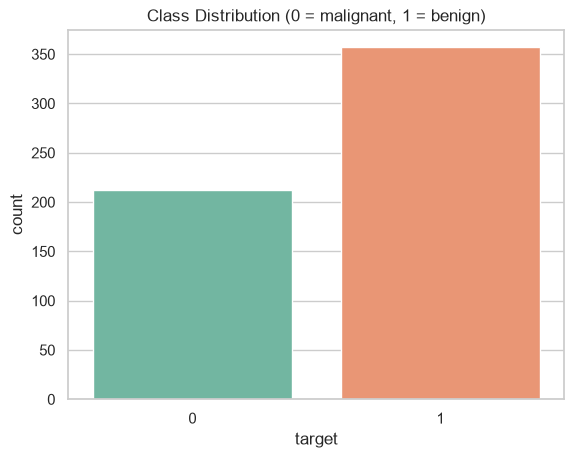

In [3]:
# Checking class distribution (balanced or imbalanced dataset)
print("Class Distribution: \n")
print(df["target"].value_counts())

sns.countplot(x="target", data=df, hue="target", palette="Set2", hue_order=[0, 1], legend=False)
plt.title("Class Distribution (0 = malignant, 1 = benign)")
plt.show()

In [4]:
# Missing Values Check 
print("Missing Values in DataSet: ", df.isnull().sum().sum())

Missing Values in DataSet:  0


### Step 4: Feature and Target Selection

In [5]:
# Splitting into independent features (X) and target variable (y)

X = df.drop("target", axis=1)
y = df["target"]

print("Shape of Features (X): ", X.shape[1])
print("Shape of Target   (y): ", y.shape[0])

Shape of Features (X):  30
Shape of Target   (y):  569


### Step 5: Split Data into Training and Testing Sets

In [6]:
# Splitting data: 80% training, 20% testing (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size: ", X_train.shape)
print("Testing  set size: ", X_test.shape)

Training set size:  (455, 30)
Testing  set size:  (114, 30)


### STep 6: Feature Scaling

In [7]:
# Logistic Regression Model works best when features are on the same scale, so we will standardize the features using StandardScaler
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


### Step 7: Build and Train the Logistic Regression Model

In [8]:
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


### Step 8: Make Predictions on the Test Data

In [9]:
y_pred        = model.predict(X_test_scaled)

y_pred_proba  = model.predict_proba(X_test_scaled)[:, 1]  # Probability estimates for the positive class

comparison_df = pd.DataFrame({"Actual": y_test.values[:10], "Predicted": y_pred[:10], "Probability": y_pred_proba[:10]})

print("Comparison of Actual vs Predicted (first 10 samples):")
print(comparison_df)

Comparison of Actual vs Predicted (first 10 samples):
   Actual  Predicted   Probability
0       0          0  5.888242e-08
1       1          1  9.999887e-01
2       0          0  6.410825e-03
3       1          1  5.335085e-01
4       0          0  6.525001e-10
5       1          1  9.921604e-01
6       1          1  9.999828e-01
7       0          0  5.635275e-07
8       0          0  5.431637e-05
9       0          0  8.041849e-11


### Step 9: Confusion Matrix 

Confusion Matrix: 
 [[41  1]
 [ 1 71]]


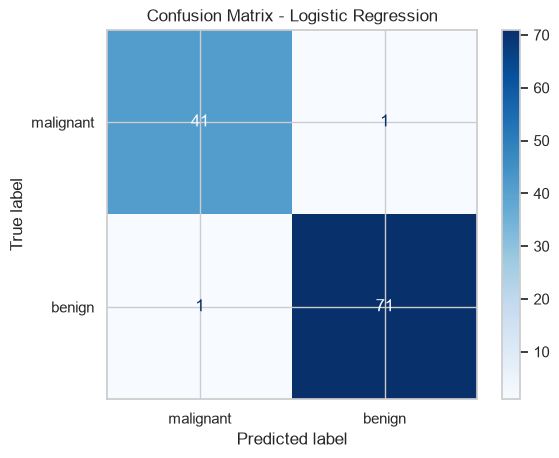

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix: \n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Step 10: Evaluation Metrices - Accuracy, Precision, Recall, F1-score

In [11]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Model Evaluation Metrics: ")
print("-" * 30)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Evaluation Metrics: 
------------------------------
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861


In [12]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Classification Report: 

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Step 11: ROC Curve and AUC Score

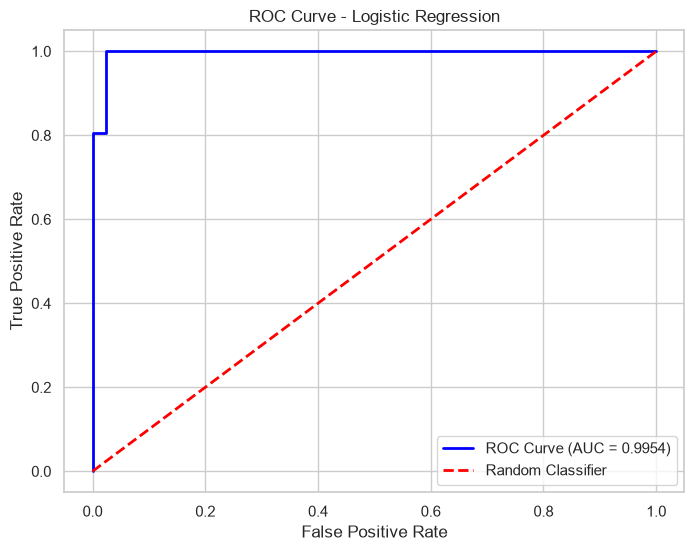

AUC Score: 0.9954


In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score            = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier', color='red', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

### Step 12: Final Output 

In [14]:
print("Experiment Completed Successfully!")
print("\nFinal Model Performance Summary: ")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC Score : {auc_score:.4f}")

Experiment Completed Successfully!

Final Model Performance Summary: 
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861
AUC Score : 0.9954
